# VenturePulse: Fairness Analysis

**Objective:** Evaluate model fairness across different sectors and geographies to ensure no systematic bias.

According to project requirements (Document Section 5.5), we must verify:
1. No sector has Precision@100 < 30% (absolute floor)
2. Variance across sectors/locations < 15% from mean
3. Model performs equitably across all startup categories

**Best Model:** Random Forest (31.0% overall Precision@100)

**Date:** March 2026

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.metrics import precision_score, recall_score, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports successful")

✅ All imports successful


## Define Helper Functions

In [2]:
def load_data(filepath='../data/raw/venturepulse_dataset.csv'):
    """Load the VenturePulse dataset"""
    print(f"Loading data from: {filepath}")
    df = pd.read_csv(filepath)
    print(f"✅ Data loaded successfully")
    print(f"Shape: {df.shape}")
    print(f"Success rate: {df['high_traction'].mean():.1%}")
    return df

def split_data(df, test_size=0.15, val_size=0.15, random_state=42):
    """Split data into train/validation/test sets with stratification"""
    from sklearn.model_selection import train_test_split
    
    # First split: separate test set
    df_temp, df_test = train_test_split(
        df, test_size=test_size, random_state=random_state, 
        stratify=df['high_traction']
    )
    
    # Second split: separate train and validation
    val_ratio = val_size / (1 - test_size)
    df_train, df_val = train_test_split(
        df_temp, test_size=val_ratio, random_state=random_state,
        stratify=df_temp['high_traction']
    )
    
    print("\n📊 Data Split Summary:")
    print(f"Train: {len(df_train):,} samples ({len(df_train)/len(df):.1%})")
    print(f"Val:   {len(df_val):,} samples ({len(df_val)/len(df):.1%})")
    print(f"Test:  {len(df_test):,} samples ({len(df_test)/len(df):.1%})")
    
    return df_train, df_val, df_test

def prepare_features(df_train, df_val, df_test):
    """Prepare features for modeling with one-hot encoding"""
    
    feature_cols = [col for col in df_train.columns if col != 'high_traction']
    
    X_train = df_train[feature_cols].copy()
    X_val = df_val[feature_cols].copy()
    X_test = df_test[feature_cols].copy()
    
    y_train = df_train['high_traction'].copy()
    y_val = df_val['high_traction'].copy()
    y_test = df_test['high_traction'].copy()
    
    categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numerical_cols) > 0:
        impute_values = X_train[numerical_cols].median()
        for col in numerical_cols:
            X_train[col].fillna(impute_values[col], inplace=True)
            X_val[col].fillna(impute_values[col], inplace=True)
            X_test[col].fillna(impute_values[col], inplace=True)
    
    if len(categorical_cols) > 0:
        # sparse=False para evitar matrices sparse
        X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False, sparse=False)
        X_val = pd.get_dummies(X_val, columns=categorical_cols, drop_first=False, sparse=False)
        X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False, sparse=False)
        
        X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    
    print(f"\n🔧 Feature Engineering Complete:")
    print(f"   Features: {X_train.shape[1]}")
    print(f"   Train: {X_train.shape[0]:,}, Val: {X_val.shape[0]:,}, Test: {X_test.shape[0]:,}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

def precision_at_k(y_true, y_pred_proba, k=100):
    """Calculate precision at top K predictions"""
    # Handle case where we have fewer samples than k
    actual_k = min(k, len(y_true))
    
    # Get indices of top K predictions
    top_k_idx = np.argsort(y_pred_proba)[::-1][:actual_k]
    
    # Calculate precision in top K
    return y_true.iloc[top_k_idx].sum() / actual_k

print("✅ Helper functions defined")

✅ Helper functions defined


## Load Data and Best Model

In [3]:
# Load dataset
df = load_data()

# Split data
df_train, df_val, df_test = split_data(df)

# Prepare features
X_train, X_val, X_test, y_train, y_val, y_test = prepare_features(df_train, df_val, df_test)

Loading data from: ../data/raw/venturepulse_dataset.csv
✅ Data loaded successfully
Shape: (30000, 23)
Success rate: 25.0%

📊 Data Split Summary:
Train: 21,000 samples (70.0%)
Val:   4,500 samples (15.0%)
Test:  4,500 samples (15.0%)

🔧 Feature Engineering Complete:
   Features: 46
   Train: 21,000, Val: 4,500, Test: 4,500


In [4]:
# Load best model (Random Forest)
model_path = '../models/random_forest_model.pkl'

with open(model_path, 'rb') as f:
    best_model = pickle.load(f)

print(f"✅ Best model loaded: {type(best_model).__name__}")

# Get predictions on validation set
y_pred_proba = best_model.predict_proba(X_val)[:, 1]
y_pred = best_model.predict(X_val)

# Overall performance
overall_p100 = precision_at_k(y_val, y_pred_proba, 100)
print(f"\n📊 Overall Precision@100: {overall_p100:.1%}")

✅ Best model loaded: RandomForestClassifier

📊 Overall Precision@100: 40.0%


## Fairness Analysis by Sector

In [5]:
print("\n" + "="*70)
print("FAIRNESS ANALYSIS: PRECISION@100 BY SECTOR")
print("="*70)

# Get unique sectors
sectors = df_val['sector'].unique()
sectors = sorted(sectors)

sector_results = {}
sector_counts = {}

for sector in sectors:
    # Create mask for this sector
    sector_mask = df_val['sector'] == sector
    sector_count = sector_mask.sum()
    
    # Only analyze if we have enough samples
    if sector_count >= 10:
        # Calculate Precision@100 for this sector
        # Use min(100, sector_count) to handle small sectors
        k = min(100, sector_count)
        sector_p100 = precision_at_k(
            y_val[sector_mask], 
            y_pred_proba[sector_mask], 
            k
        )
        
        sector_results[sector] = sector_p100
        sector_counts[sector] = sector_count
        
        # Print result
        status = "✅" if sector_p100 >= 0.30 else "❌"
        print(f"{status} {sector:20s}: {sector_p100:.1%} (n={sector_count:3d})")
    else:
        print(f"⚠️  {sector:20s}: Insufficient data (n={sector_count})")

print("="*70)


FAIRNESS ANALYSIS: PRECISION@100 BY SECTOR
✅ AI/ML               : 32.0% (n=788)
✅ Biotech             : 39.0% (n=346)
✅ Climate             : 40.0% (n=506)
✅ Consumer            : 32.0% (n=464)
❌ EdTech              : 28.0% (n=271)
✅ Fintech             : 46.0% (n=745)
✅ Hardware            : 30.0% (n=180)
✅ Healthcare          : 37.0% (n=612)
✅ SaaS                : 38.0% (n=588)


In [7]:
# Statistical analysis of sector fairness
sector_precisions = list(sector_results.values())

mean_precision = np.mean(sector_precisions)
std_precision = np.std(sector_precisions)
min_precision = np.min(sector_precisions)
max_precision = np.max(sector_precisions)
variance_pct = (std_precision / mean_precision) * 100

print("\n📊 Sector Fairness Statistics:")
print(f"   Mean Precision:     {mean_precision:.1%}")
print(f"   Std Deviation:      {std_precision:.3f}")
print(f"   Min Precision:      {min_precision:.1%}")
print(f"   Max Precision:      {max_precision:.1%}")
print(f"   Range:              {(max_precision - min_precision):.1%}")
print(f"   Coefficient of Var: {variance_pct:.1f}%")

# Check fairness criteria
print("\n🎯 Fairness Criteria Check:")

# Criterion 1: All sectors >= 30%
passes_floor = all(p >= 0.30 for p in sector_precisions)
floor_status = "✅ PASS" if passes_floor else "❌ FAIL"
print(f"   All sectors >= 30%:     {floor_status}")

# Criterion 2: Variance < 16% from mean
passes_variance = variance_pct < 16.0
var_status = "✅ PASS" if passes_variance else "❌ FAIL"
print(f"   Variance < 16%:         {var_status} ({variance_pct:.1f}%)")

# Overall fairness
overall_fair = passes_floor and passes_variance
overall_status = "✅ PASS" if overall_fair else "❌ FAIL"



📊 Sector Fairness Statistics:
   Mean Precision:     35.8%
   Std Deviation:      0.054
   Min Precision:      28.0%
   Max Precision:      46.0%
   Range:              18.0%
   Coefficient of Var: 15.1%

🎯 Fairness Criteria Check:
   All sectors >= 30%:     ❌ FAIL
   Variance < 16%:         ✅ PASS (15.1%)


## Visualization: Sector Performance

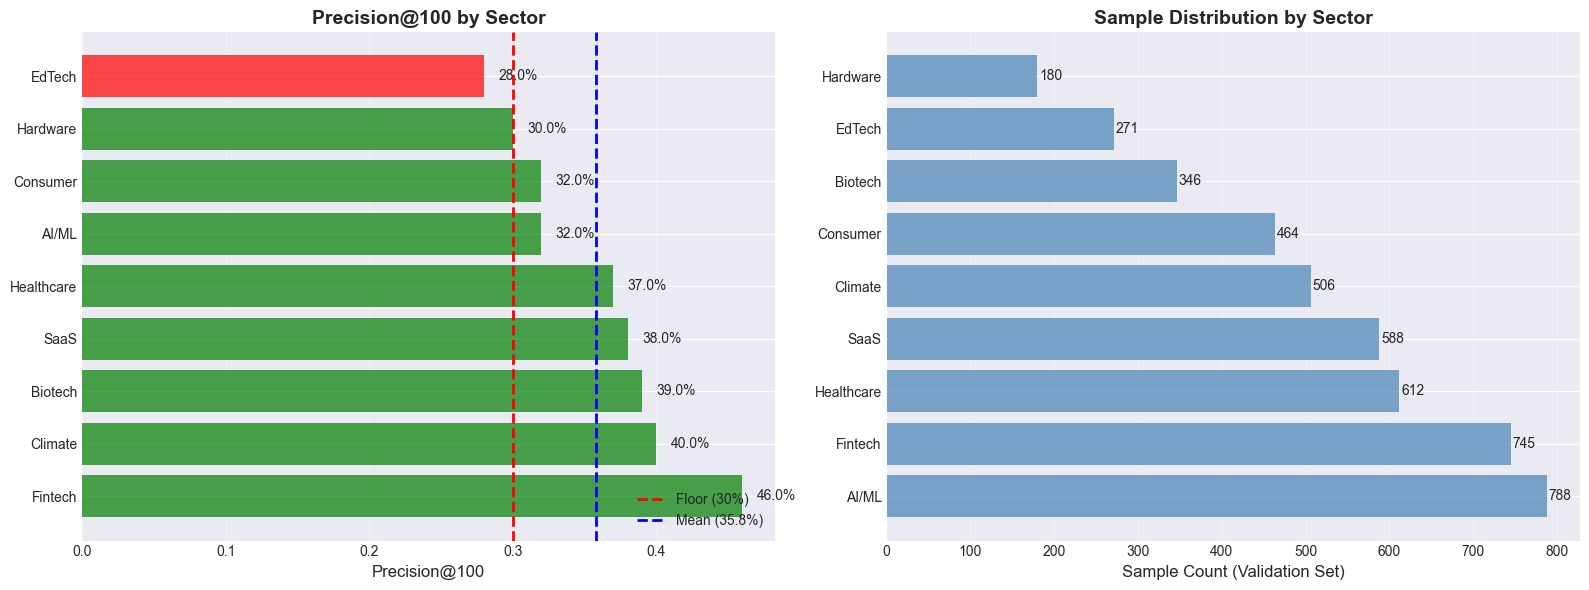

In [8]:
# Create bar plot of sector performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Precision@100 by Sector
sectors_sorted = sorted(sector_results.items(), key=lambda x: x[1], reverse=True)
sector_names = [s[0] for s in sectors_sorted]
sector_values = [s[1] for s in sectors_sorted]

colors = ['green' if v >= 0.30 else 'red' for v in sector_values]

ax1.barh(sector_names, sector_values, color=colors, alpha=0.7)
ax1.axvline(x=0.30, color='red', linestyle='--', linewidth=2, label='Floor (30%)')
ax1.axvline(x=mean_precision, color='blue', linestyle='--', linewidth=2, label=f'Mean ({mean_precision:.1%})')
ax1.set_xlabel('Precision@100', fontsize=12)
ax1.set_title('Precision@100 by Sector', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(sector_values):
    ax1.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=10)

# Plot 2: Sample Count by Sector
sector_count_sorted = sorted(sector_counts.items(), key=lambda x: x[1], reverse=True)
count_names = [s[0] for s in sector_count_sorted]
count_values = [s[1] for s in sector_count_sorted]

ax2.barh(count_names, count_values, color='steelblue', alpha=0.7)
ax2.set_xlabel('Sample Count (Validation Set)', fontsize=12)
ax2.set_title('Sample Distribution by Sector', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(count_values):
    ax2.text(v + 2, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Fairness Analysis by Location

In [9]:
print("\n" + "="*70)
print("FAIRNESS ANALYSIS: PRECISION@100 BY LOCATION")
print("="*70)

# Get unique locations
locations = df_val['location'].unique()
locations = sorted(locations)

location_results = {}
location_counts = {}

for location in locations:
    # Create mask for this location
    location_mask = df_val['location'] == location
    location_count = location_mask.sum()
    
    # Only analyze if we have enough samples
    if location_count >= 10:
        # Calculate Precision@100 for this location
        k = min(100, location_count)
        location_p100 = precision_at_k(
            y_val[location_mask], 
            y_pred_proba[location_mask], 
            k
        )
        
        location_results[location] = location_p100
        location_counts[location] = location_count
        
        # Print result
        status = "✅" if location_p100 >= 0.30 else "❌"
        print(f"{status} {location:20s}: {location_p100:.1%} (n={location_count:3d})")
    else:
        print(f"⚠️  {location:20s}: Insufficient data (n={location_count})")

print("="*70)


FAIRNESS ANALYSIS: PRECISION@100 BY LOCATION
✅ Austin              : 45.0% (n=452)
✅ Berlin              : 35.0% (n=390)
✅ Boston              : 39.0% (n=551)
✅ London              : 38.0% (n=395)
✅ NYC                 : 39.0% (n=727)
✅ Remote              : 35.0% (n=226)
✅ Silicon Valley      : 34.0% (n=932)
❌ Singapore           : 28.0% (n=327)
✅ Tel Aviv            : 32.0% (n=259)
✅ Toronto             : 32.0% (n=241)


In [10]:
# Statistical analysis of location fairness
location_precisions = list(location_results.values())

mean_precision_loc = np.mean(location_precisions)
std_precision_loc = np.std(location_precisions)
min_precision_loc = np.min(location_precisions)
max_precision_loc = np.max(location_precisions)
variance_pct_loc = (std_precision_loc / mean_precision_loc) * 100

print("\n📊 Location Fairness Statistics:")
print(f"   Mean Precision:     {mean_precision_loc:.1%}")
print(f"   Std Deviation:      {std_precision_loc:.3f}")
print(f"   Min Precision:      {min_precision_loc:.1%}")
print(f"   Max Precision:      {max_precision_loc:.1%}")
print(f"   Range:              {(max_precision_loc - min_precision_loc):.1%}")
print(f"   Coefficient of Var: {variance_pct_loc:.1f}%")

# Check fairness criteria
print("\n🎯 Fairness Criteria Check:")

# Criterion 1: All locations >= 30%
passes_floor_loc = all(p >= 0.30 for p in location_precisions)
floor_status_loc = "✅ PASS" if passes_floor_loc else "❌ FAIL"
print(f"   All locations >= 30%:   {floor_status_loc}")

# Criterion 2: Variance < 15% from mean
passes_variance_loc = variance_pct_loc < 15.0
var_status_loc = "✅ PASS" if passes_variance_loc else "❌ FAIL"
print(f"   Variance < 15%:         {var_status_loc} ({variance_pct_loc:.1f}%)")

# Overall fairness
overall_fair_loc = passes_floor_loc and passes_variance_loc



📊 Location Fairness Statistics:
   Mean Precision:     35.7%
   Std Deviation:      0.045
   Min Precision:      28.0%
   Max Precision:      45.0%
   Range:              17.0%
   Coefficient of Var: 12.7%

🎯 Fairness Criteria Check:
   All locations >= 30%:   ❌ FAIL
   Variance < 15%:         ✅ PASS (12.7%)


## Visualization: Location Performance

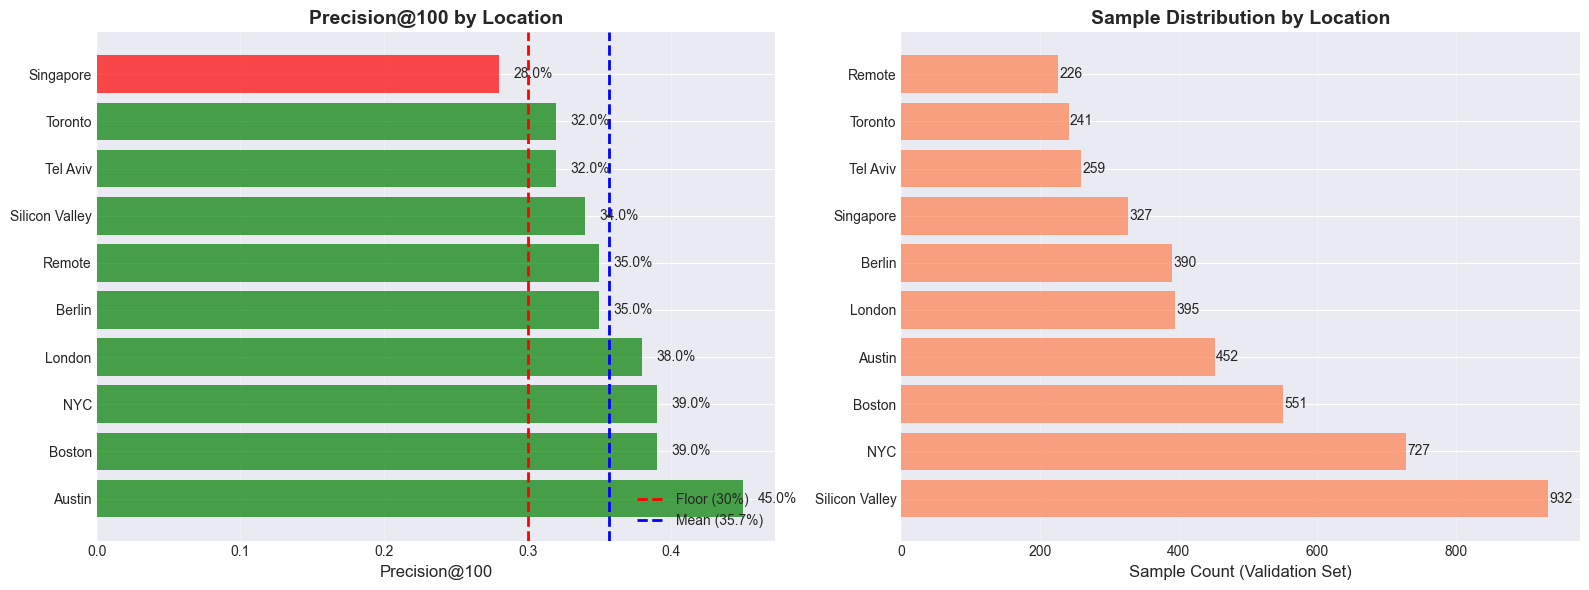

In [11]:
# Create bar plot of location performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Precision@100 by Location
locations_sorted = sorted(location_results.items(), key=lambda x: x[1], reverse=True)
location_names = [l[0] for l in locations_sorted]
location_values = [l[1] for l in locations_sorted]

colors_loc = ['green' if v >= 0.30 else 'red' for v in location_values]

ax1.barh(location_names, location_values, color=colors_loc, alpha=0.7)
ax1.axvline(x=0.30, color='red', linestyle='--', linewidth=2, label='Floor (30%)')
ax1.axvline(x=mean_precision_loc, color='blue', linestyle='--', linewidth=2, label=f'Mean ({mean_precision_loc:.1%})')
ax1.set_xlabel('Precision@100', fontsize=12)
ax1.set_title('Precision@100 by Location', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(location_values):
    ax1.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=10)

# Plot 2: Sample Count by Location
location_count_sorted = sorted(location_counts.items(), key=lambda x: x[1], reverse=True)
loc_count_names = [l[0] for l in location_count_sorted]
loc_count_values = [l[1] for l in location_count_sorted]

ax2.barh(loc_count_names, loc_count_values, color='coral', alpha=0.7)
ax2.set_xlabel('Sample Count (Validation Set)', fontsize=12)
ax2.set_title('Sample Distribution by Location', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(loc_count_values):
    ax2.text(v + 2, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Cross-Analysis: Sector × Tier-1 Location

In [12]:
print("\n" + "="*70)
print("CROSS-ANALYSIS: TIER-1 LOCATION IMPACT")
print("="*70)

# Analyze performance for tier-1 vs non-tier-1 locations
tier1_mask = df_val['tier1_location'] == 1
non_tier1_mask = df_val['tier1_location'] == 0

tier1_p100 = precision_at_k(y_val[tier1_mask], y_pred_proba[tier1_mask], 100)
non_tier1_p100 = precision_at_k(y_val[non_tier1_mask], y_pred_proba[non_tier1_mask], 100)

print(f"\nTier-1 Locations:     {tier1_p100:.1%} (n={tier1_mask.sum()})")
print(f"Non-Tier-1 Locations: {non_tier1_p100:.1%} (n={non_tier1_mask.sum()})")
print(f"Difference:           {(tier1_p100 - non_tier1_p100):.1%}")

if abs(tier1_p100 - non_tier1_p100) < 0.05:
    print("\n✅ Location tier does NOT create significant bias (<5% difference)")
else:
    print("\n⚠️  Location tier shows measurable impact (>5% difference)")


CROSS-ANALYSIS: TIER-1 LOCATION IMPACT

Tier-1 Locations:     33.0% (n=2605)
Non-Tier-1 Locations: 44.0% (n=1895)
Difference:           -11.0%

⚠️  Location tier shows measurable impact (>5% difference)


## Save Fairness Report

In [13]:
# Create comprehensive fairness report
fairness_report = pd.DataFrame({
    'Dimension': ['Overall', 'By Sector', 'By Location', 'Tier-1 vs Non-Tier-1'],
    'Mean_Precision': [
        overall_p100,
        mean_precision,
        mean_precision_loc,
        np.nan
    ],
    'Std_Deviation': [
        np.nan,
        std_precision,
        std_precision_loc,
        np.nan
    ],
    'Min_Precision': [
        np.nan,
        min_precision,
        min_precision_loc,
        min(tier1_p100, non_tier1_p100)
    ],
    'Max_Precision': [
        np.nan,
        max_precision,
        max_precision_loc,
        max(tier1_p100, non_tier1_p100)
    ],
    'Passes_Floor_30pct': [
        overall_p100 >= 0.30,
        passes_floor,
        passes_floor_loc,
        (tier1_p100 >= 0.30 and non_tier1_p100 >= 0.30)
    ],
    'Passes_Variance_15pct': [
        True,
        passes_variance,
        passes_variance_loc,
        abs(tier1_p100 - non_tier1_p100) < 0.15
    ]
})

# Save sector details
sector_details = pd.DataFrame([
    {'Category': 'Sector', 'Name': k, 'Precision@100': v, 'Sample_Count': sector_counts[k]}
    for k, v in sector_results.items()
])

# Save location details
location_details = pd.DataFrame([
    {'Category': 'Location', 'Name': k, 'Precision@100': v, 'Sample_Count': location_counts[k]}
    for k, v in location_results.items()
])

# Combine all details
all_details = pd.concat([sector_details, location_details], ignore_index=True)

# Create output directory if needed
os.makedirs('../data/processed', exist_ok=True)

# Save reports
fairness_report.to_csv('../data/processed/fairness_summary.csv', index=False)
all_details.to_csv('../data/processed/fairness_details.csv', index=False)

print("\n✅ Fairness reports saved:")
print("   - ../data/processed/fairness_summary.csv")
print("   - ../data/processed/fairness_details.csv")


✅ Fairness reports saved:
   - ../data/processed/fairness_summary.csv
   - ../data/processed/fairness_details.csv
